In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve)

In [12]:
df = pd.read_csv("train.csv")
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [13]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [14]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [15]:
df["target"].value_counts()

,count
target,
0,179902
1,20098


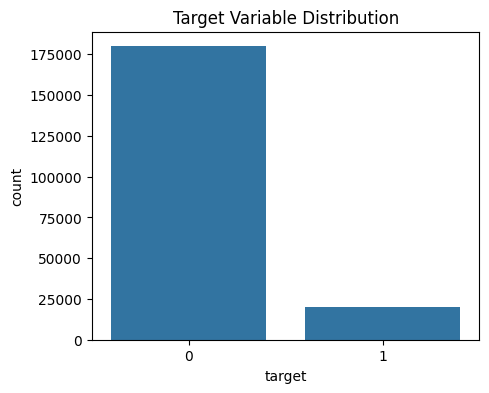

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Target Variable Distribution")
plt.show()

In [17]:
X = df.drop(["ID_code", "target"], axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression(C=1,max_iter=1000,random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(C=1, max_iter=1000, random_state=42)

In [21]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

Accuracy : 0.9134
Precision: 0.682175622542595
Recall   : 0.258955223880597
F1 Score : 0.3754056978002164
ROC AUC  : 0.8598618773835104


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35980
           1       0.68      0.26      0.38      4020

    accuracy                           0.91     40000
   macro avg       0.80      0.62      0.66     40000
weighted avg       0.90      0.91      0.90     40000



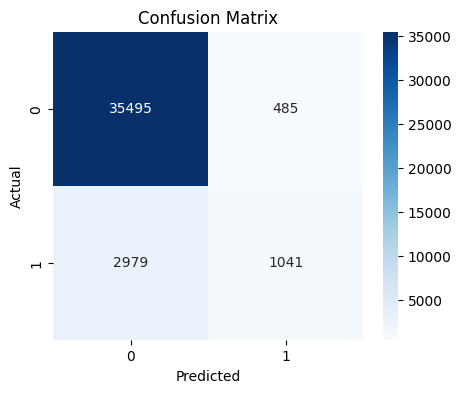

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

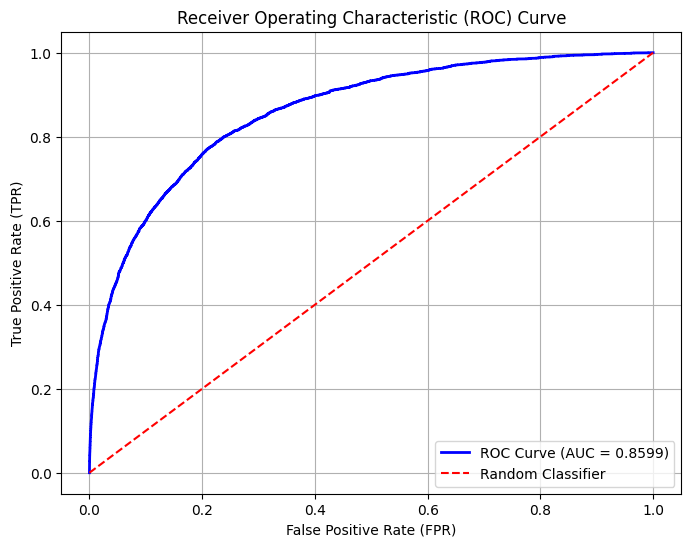

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [26]:
C_values = [0.01, 0.1, 1, 10, 100]
results = []
for c in C_values:
    model = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:,1]
    results.append({
        "C": c,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    })

In [27]:
results_df = pd.DataFrame(results)
results_df

,C,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.01,0.913250,0.682119,0.256219,0.372514,0.859865
1,0.10,0.913425,0.682863,0.258706,0.375248,0.859862
2,1.00,0.913400,0.682176,0.258955,0.375406,0.859862
3,10.00,0.913400,0.682176,0.258955,0.375406,0.859862
4,100.00,0.913400,0.682176,0.258955,0.375406,0.859862


Summary of Findings-

The Santander Customer Transaction dataset required preprocessing, including checking for missing values, feature scaling, and train-test splitting.

No missing values were found in the dataset.

Feature scaling significantly improved the efficiency and convergence of the Logistic Regression model.

Different values of the regularization parameter (C) were tested to analyze their effect on model performance. A moderate value (around C = 1) generally achieved the best balance between underfitting and overfitting.

The dataset exhibited class imbalance; therefore, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC were more informative than accuracy alone.

The ROC curve demonstrated that the model was able to distinguish between the two classes effectively, indicating satisfactory classification performance.

Overall, Logistic Regression proved to be a simple, efficient, and interpretable baseline model for the Santander Customer Transaction Prediction dataset after proper preprocessing and feature scaling.

Observations-

The model performance remained almost identical for all values of C.

Accuracy stayed around 91.34%, while the ROC-AUC remained close to 0.86.

Precision remained consistently high (around 68.2%), whereas Recall stayed relatively low (around 25.9%).

Increasing C beyond 1 did not improve the model, indicating that the default level of regularization already provides an optimal balance for this dataset.

This suggests that the Logistic Regression model is not highly sensitive to the tested regularization strengths.